In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
#load data

df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [37]:
df.sample()

,clean_comment,category
29845,very cute idea,1


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [39]:
df.shape

(37249, 2)

In [40]:
df.columns

Index(['clean_comment', 'category'], dtype='object')

In [41]:
df.describe()

,category
count,37249.000000
mean,0.202771
std,0.778515
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [42]:
df["clean_comment"].isnull().sum()

np.int64(100)

In [43]:
df.isnull()

,clean_comment,category
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
37244,False,False
37245,False,False
37246,False,False
37247,False,False


In [44]:
df.dropna(inplace=True)

In [45]:
df["clean_comment"].isnull().sum()

np.int64(0)

In [46]:
df.isnull().sum()

,0
clean_comment,0
category,0


In [47]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
37244,False
37245,False
37246,False
37247,False


In [48]:
df.drop_duplicates()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [49]:
df["category"].value_counts()

,count
category,
1,15830
0,13042
-1,8277


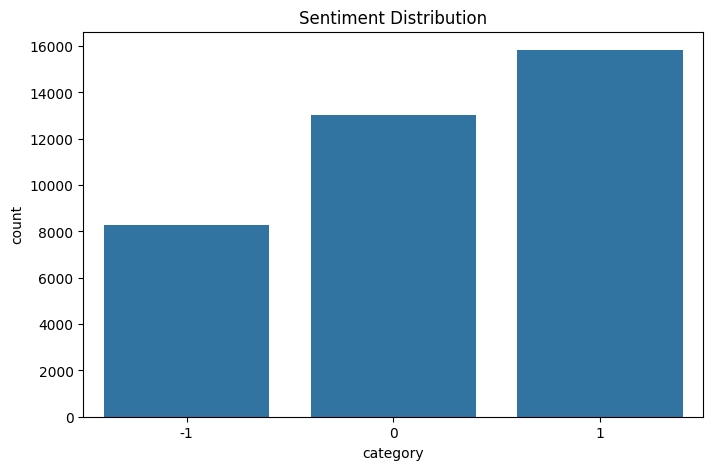

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="category")
plt.title("Sentiment Distribution")
plt.show()

In [51]:
df['word_count'] = df["clean_comment"].apply(lambda x: len(x.split()))

In [52]:
df["word_count"]

,word_count
0,39
1,196
2,86
3,29
4,112
...,...
37244,1
37245,19
37246,6
37247,2


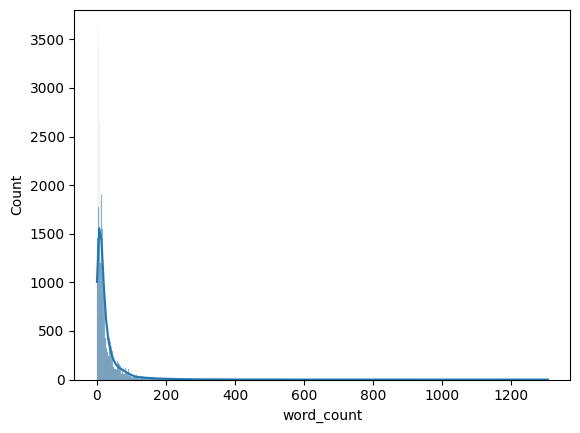

In [53]:
sns.histplot(df["word_count"],kde=True)
plt.show()

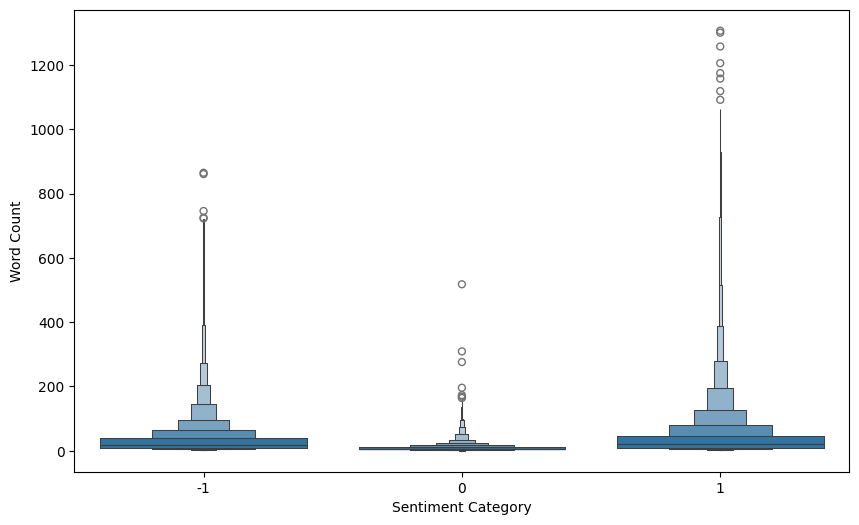

In [54]:
plt.figure(figsize=(10,6))
sns.boxenplot(data =df,x="category",y="word_count",)
plt.xlabel("Sentiment Category")
plt.ylabel("Word Count")
plt.show()

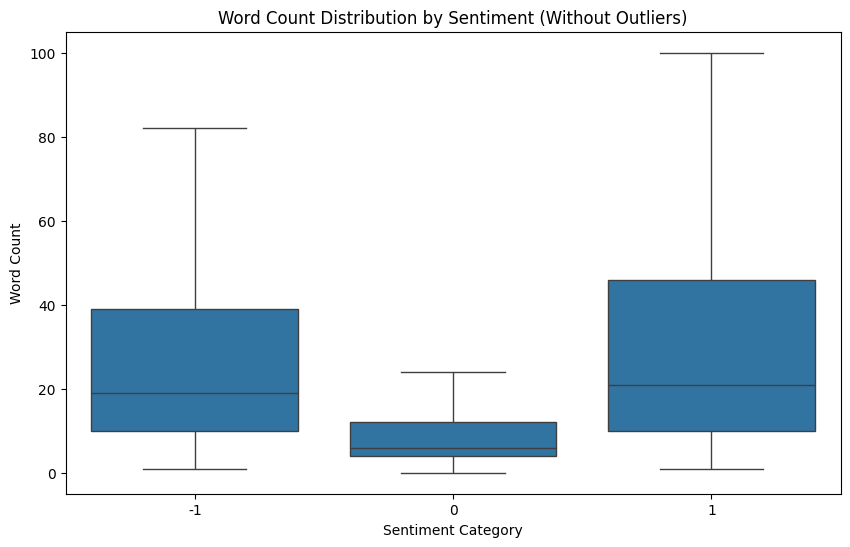

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="category",
    y="word_count",
    showfliers=False
)

plt.title("Word Count Distribution by Sentiment (Without Outliers)")
plt.xlabel("Sentiment Category")
plt.ylabel("Word Count")

plt.show()

In [57]:
df.shape

(37149, 3)

In [58]:
df.isnull().sum()

,0
clean_comment,0
category,0
word_count,0


In [59]:
df[df["clean_comment"].str.strip()==""]

,clean_comment,category,word_count
181,,0,0
375,,0,0
392,,0,0
651,,0,0
1222,,0,0
...,...,...,...
35711,,0,0
35778,,0,0
35987,,0,0
36707,,0,0


In [60]:
df.to_csv("reddit_clean.csv")